In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import factorial

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

LAMBDA = 10.0
MU = 3.0
N_CHANNELS = 4

LAMBDA, MU, N_CHANNELS

(10.0, 3.0, 4)

In [ ]:
def mm_n_inf_metrics(lambda_rate: float, mu: float, n: int) -> dict | None:
    rho = lambda_rate / (n * mu)
    if rho >= 1.0:
        return None

    a = lambda_rate / mu
    k = np.arange(0, n, dtype=float)
    sum_part = np.sum(a**k / factorial(k))
    tail = (a**n / factorial(n)) * (1.0 / (1.0 - rho))
    inv_p0 = sum_part + tail
    p0 = 1.0 / inv_p0

    p_wait = p0 * (a**n / factorial(n)) * (1.0 / (1.0 - rho))

    lq = p0 * (a**n / factorial(n)) * rho / (1.0 - rho) ** 2
    wq = lq / lambda_rate
    w_sys = wq + 1.0 / mu

    return {
        "lambda": lambda_rate,
        "mu": mu,
        "n": n,
        "rho": rho,
        "a_erlang": a,
        "P0": p0,
        "P_wait": p_wait,
        "Lq": lq,
        "Wq": wq,
        "W": w_sys,
    }


base = mm_n_inf_metrics(LAMBDA, MU, N_CHANNELS)
base

{'lambda': 10.0,
 'mu': 3.0,
 'n': 4,
 'rho': 0.8333333333333334,
 'a_erlang': 3.3333333333333335,
 'P0': np.float64(0.021310181531175997),
 'P_wait': np.float64(0.6577216521967904),
 'Lq': np.float64(3.288608260983952),
 'Wq': np.float64(0.32886082609839523),
 'W': np.float64(0.6621941594317285)}

In [4]:
def metrics_to_row(d: dict) -> dict:
    return {
        "λ": d["lambda"],
        "μ": d["mu"],
        "n": d["n"],
        "ρ = λ/(nμ)": d["rho"],
        "P0 (все каналы свободны)": d["P0"],
        "P_wait (ждёт в очереди)": d["P_wait"],
        "Lq (ср. число в очереди)": d["Lq"],
        "Wq (ср. время ожидания)": d["Wq"],
        "W (ср. время в системе)": d["W"],
    }


df_base = pd.DataFrame([metrics_to_row(base)])
df_base

,λ,μ,n,ρ = λ/(nμ),P0 (все каналы свободны),P_wait (ждёт в очереди),Lq (ср. число в очереди),Wq (ср. время ожидания),W (ср. время в системе)
0,10.0,3.0,4,0.833333,0.02131,0.657722,3.288608,0.328861,0.662194


In [ ]:
n_min = int(np.ceil(LAMBDA / MU))
n_values = np.arange(n_min, n_min + 10)

rows_n = []
for nn in n_values:
    m = mm_n_inf_metrics(LAMBDA, MU, int(nn))
    if m is None:
        continue
    rows_n.append(
        {
            "n": int(nn),
            "ρ": m["rho"],
            "P0": m["P0"],
            "P_wait": m["P_wait"],
            "Lq": m["Lq"],
            "Wq": m["Wq"],
            "W": m["W"],
        }
    )

df_by_n = pd.DataFrame(rows_n)
df_by_n

,n,ρ,P0,P_wait,Lq,Wq,W
0,4,0.833333,0.021310,0.657722,3.288608,0.328861,0.662194
1,5,0.666667,0.031752,0.326669,0.653339,0.065334,0.398667
2,6,0.555556,0.034576,0.148217,0.185271,0.018527,0.351860
3,7,0.476190,0.035370,0.061261,0.055692,0.005569,0.338903
4,8,0.416667,0.035593,0.023065,0.016475,0.001648,0.334981
5,9,0.370370,0.035653,0.007928,0.004663,0.000466,0.333800
6,10,0.333333,0.035669,0.002497,0.001248,0.000125,0.333458
7,11,0.303030,0.035673,0.000724,0.000315,0.000031,0.333365
8,12,0.277778,0.035674,0.000194,0.000075,0.000007,0.333341
9,13,0.256410,0.035674,0.000048,0.000017,0.000002,0.333335


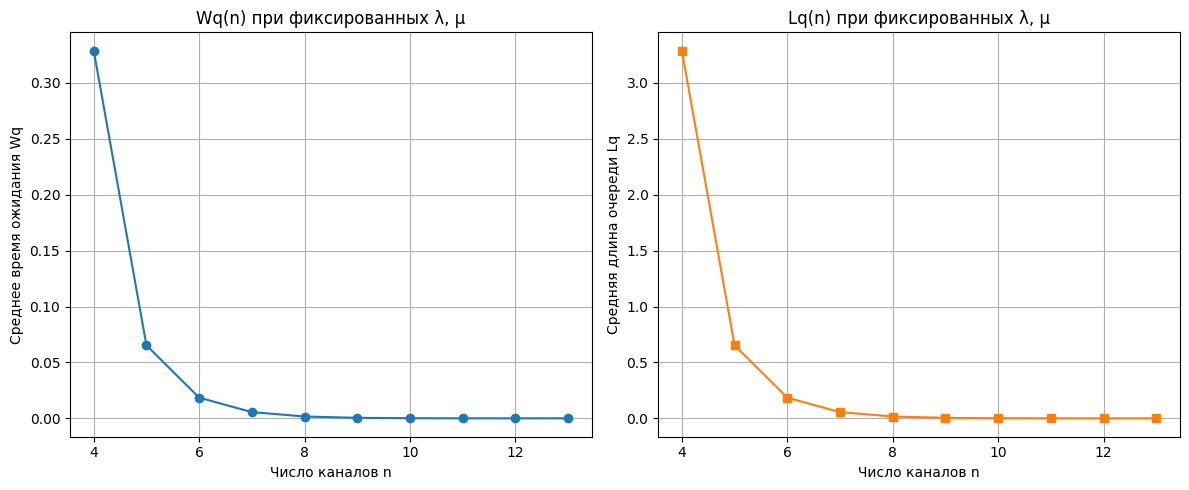

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(df_by_n["n"], df_by_n["Wq"], "o-", label="Wq")
ax[0].set_xlabel("Число каналов n")
ax[0].set_ylabel("Среднее время ожидания Wq")
ax[0].set_title("Wq(n) при фиксированных λ, μ")

ax[1].plot(df_by_n["n"], df_by_n["Lq"], "s-", color="C1", label="Lq")
ax[1].set_xlabel("Число каналов n")
ax[1].set_ylabel("Средняя длина очереди Lq")
ax[1].set_title("Lq(n) при фиксированных λ, μ")

plt.tight_layout()
plt.show()

In [7]:
mu_values = np.linspace(2.0, 8.0, 13)
rows_mu = []
for mu_i in mu_values:
    m = mm_n_inf_metrics(LAMBDA, float(mu_i), N_CHANNELS)
    if m is None:
        continue
    rows_mu.append(
        {
            "μ": mu_i,
            "ρ": m["rho"],
            "P_wait": m["P_wait"],
            "Lq": m["Lq"],
            "Wq": m["Wq"],
            "W": m["W"],
        }
    )

df_by_mu = pd.DataFrame(rows_mu)
df_by_mu

,μ,ρ,P_wait,Lq,Wq,W
0,3.0,0.833333,0.657722,3.288608,0.328861,0.662194
1,3.5,0.714286,0.451080,1.127701,0.112770,0.398484
2,4.0,0.625000,0.319857,0.533095,0.053309,0.303309
3,4.5,0.555556,0.233133,0.291416,0.029142,0.251364
4,5.0,0.500000,0.173913,0.173913,0.017391,0.217391
5,5.5,0.454545,0.132347,0.110289,0.011029,0.192847
6,6.0,0.416667,0.102476,0.073197,0.007320,0.173986
7,6.5,0.384615,0.080565,0.050353,0.005035,0.158881
8,7.0,0.357143,0.064200,0.035666,0.003567,0.146424
9,7.5,0.333333,0.051780,0.025890,0.002589,0.135922


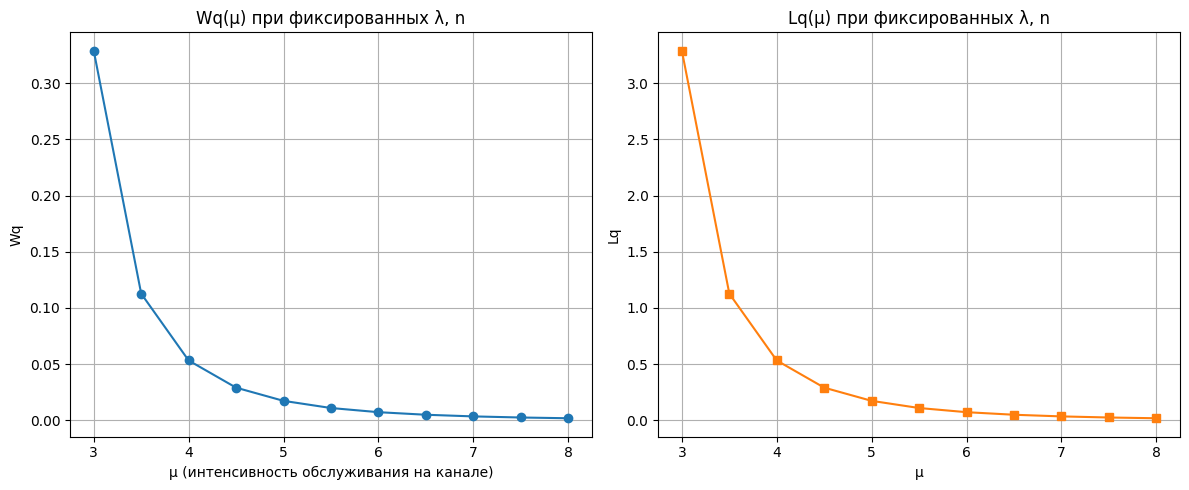

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(df_by_mu["μ"], df_by_mu["Wq"], "o-")
ax[0].set_xlabel("μ (интенсивность обслуживания на канале)")
ax[0].set_ylabel("Wq")
ax[0].set_title("Wq(μ) при фиксированных λ, n")

ax[1].plot(df_by_mu["μ"], df_by_mu["Lq"], "s-", color="C1")
ax[1].set_xlabel("μ")
ax[1].set_ylabel("Lq")
ax[1].set_title("Lq(μ) при фиксированных λ, n")

plt.tight_layout()
plt.show()

In [11]:
def simulate_mm_n_inf(lambda_rate: float, mu: float, n: int, sim_time: float = 20_000.0, warmup: float = 2_000.0, seed: int = 42) -> dict:
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=n)
    rng = np.random.default_rng(seed)

    stats = {
        "area_q": 0.0,
        "area_busy": 0.0,
        "area_empty": 0.0,
        "last_t": 0.0,
        "served": 0,
        "waited": 0,
        "sum_wq": 0.0,
        "sum_w": 0.0,
    }

    def update_time_averages(before_q: int, before_busy: int):
        t0 = max(stats["last_t"], warmup)
        t1 = env.now
        if t1 > t0:
            dt = t1 - t0
            stats["area_q"] += before_q * dt
            stats["area_busy"] += before_busy * dt
            if before_q == 0 and before_busy == 0:
                stats["area_empty"] += dt
        stats["last_t"] = env.now

    def customer(_id: int):
        arrival = env.now

        with server.request() as req:
            q_before = len(server.queue)
            busy_before = server.count

            yield req
            update_time_averages(q_before, busy_before)

            wait = env.now - arrival
            service = rng.exponential(1.0 / mu)

            q_before = len(server.queue)
            busy_before = server.count

            yield env.timeout(service)
            update_time_averages(q_before, busy_before)

            q_before = len(server.queue)
            busy_before = server.count

        update_time_averages(q_before, busy_before)

        if arrival >= warmup:
            stats["served"] += 1
            stats["sum_wq"] += wait
            stats["sum_w"] += env.now - arrival
            if wait > 0:
                stats["waited"] += 1

    def arrivals():
        i = 0
        while True:
            q_before = len(server.queue)
            busy_before = server.count
            interarrival = rng.exponential(1.0 / lambda_rate)
            yield env.timeout(interarrival)
            update_time_averages(q_before, busy_before)

            i += 1
            env.process(customer(i))

    env.process(arrivals())
    env.run(until=sim_time)

    update_time_averages(len(server.queue), server.count)

    horizon = sim_time - warmup
    served = stats["served"]

    return {
        "lambda": lambda_rate,
        "mu": mu,
        "n": n,
        "rho": (stats["area_busy"] / horizon) / n,
        "P0": stats["area_empty"] / horizon,
        "P_wait": (stats["waited"] / served) if served else np.nan,
        "Lq": stats["area_q"] / horizon,
        "Wq": (stats["sum_wq"] / served) if served else np.nan,
        "W": (stats["sum_w"] / served) if served else np.nan,
        "served": served,
        "sim_time": sim_time,
        "warmup": warmup,
        "seed": seed,
    }


sim_base = simulate_mm_n_inf(LAMBDA, MU, N_CHANNELS, sim_time=20_000, warmup=2_000, seed=42)

compare = pd.DataFrame(
    {
        "metric": ["rho", "P0", "P_wait", "Lq", "Wq", "W"],
        "theory": [base["rho"], base["P0"], base["P_wait"], base["Lq"], base["Wq"], base["W"]],
        "simulation": [sim_base["rho"], sim_base["P0"], sim_base["P_wait"], sim_base["Lq"], sim_base["Wq"], sim_base["W"]],
    }
)
compare["abs_error"] = (compare["simulation"] - compare["theory"]).abs()
compare["rel_error_%"] = np.where(compare["theory"] != 0, compare["abs_error"] / compare["theory"] * 100.0, np.nan)

print("Обслужено заявок:", sim_base["served"])
compare

Обслужено заявок: 180722


,metric,theory,simulation,abs_error,rel_error_%
0,rho,0.833333,0.850662,0.017329,2.079468
1,P0,0.021310,0.016972,0.004339,20.359485
2,P_wait,0.657722,0.664368,0.006647,1.010583
3,Lq,3.288608,3.044211,0.244397,7.431623
4,Wq,0.328861,0.332129,0.003268,0.993658
5,W,0.662194,0.665515,0.003321,0.501559
